# Importación de librerías

In [1]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import filters_and_features as ff
import data_processor as dp
import numpy as np
from sklearn.decomposition import PCA

# Importación de datos

In [2]:
df = dp.lectura(mode=1) # Leyendo 9 primeros individuos
df_val = dp.lectura(mode=2) # Leyendo 10mo individuo

Se crea el dataframe df_block

In [3]:
df_block = dp.create_df_block(df)
df_block_val = dp.create_df_block(df_val)

In [4]:
del df
del df_val

Se limpia y visualiza el contenido

In [5]:
dp.balance(df_block)
dp.balance(df_block_val)
print(df_block['stimulus'].value_counts())
print(df_block_val['stimulus'].value_counts())

stimulus
1     408
0     408
3     408
4     408
6     408
9     408
10    408
11    408
Name: count, dtype: int64
stimulus
1     48
3     48
0     48
4     48
6     48
9     48
10    48
11    48
Name: count, dtype: int64


# Filtro

In [6]:
df_block_filtered = dp.filter(df_block)
df_block_filtered_val = dp.filter(df_block_val)

Procesando: 100%|██████████| 3/3 [00:18<00:00,  6.22s/it]


In [7]:
del df_block
del df_block_val

# Extracción de características

In [8]:
df_block_features = dp.gen_carac(df_block_filtered)
df_block_features_val = dp.gen_carac(df_block_filtered_val)

Extrayendo Características:  88%|████████▊ | 2866/3264 [02:44<00:18, 21.12it/s]c:\Users\ASUS\Downloads\Proyecto PDSI\PDSI-EMG\src\filters_and_features.py:189: RuntimeWarning: invalid value encountered in scalar divide
  frecuencia_media = np.sum(xf * espectro) / np.sum(espectro)
c:\Users\ASUS\Downloads\Proyecto PDSI\PDSI-EMG\src\filters_and_features.py:189: RuntimeWarning: invalid value encountered in scalar divide
  frecuencia_media = np.sum(xf * espectro) / np.sum(espectro)
Extrayendo Características:  88%|████████▊ | 2869/3264 [02:44<00:17, 22.32it/s]c:\Users\ASUS\Downloads\Proyecto PDSI\PDSI-EMG\src\filters_and_features.py:189: RuntimeWarning: invalid value encountered in scalar divide
  frecuencia_media = np.sum(xf * espectro) / np.sum(espectro)
c:\Users\ASUS\Downloads\Proyecto PDSI\PDSI-EMG\src\filters_and_features.py:189: RuntimeWarning: invalid value encountered in scalar divide
  frecuencia_media = np.sum(xf * espectro) / np.sum(espectro)
c:\Users\ASUS\Downloads\Proyecto PDSI\

In [9]:
del df_block_filtered
del df_block_filtered_val

In [10]:
df_block_features.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,3264.000000,3.264000e+03,3264.000000,3264.000000,3264.000000,3.264000e+03,3264.000000,3.264000e+03,3264.000000,3264.000000,...,3.264000e+03,3264.000000,3.264000e+03,3.264000e+03,3264.000000,3.264000e+03,3264.000000,3264.00000,3264.000000,3264.000000
mean,0.000039,-1.434450e-09,0.000023,0.109482,0.000010,1.192915e-08,0.002080,2.649475e-12,206.800658,72.590380,...,1.617671e-06,0.006693,9.266431e-07,4.074065e-10,0.000125,9.976620e-14,233.932790,91.05576,1975.939338,5.500000
std,0.000031,9.191451e-07,0.000018,0.067986,0.000008,5.199042e-08,0.001390,1.146790e-11,25.919331,19.827986,...,3.198187e-06,0.010495,1.503548e-06,1.515021e-08,0.000311,3.904823e-12,37.041067,32.43299,477.051778,3.905723
min,0.000005,-1.358411e-05,0.000004,0.016485,0.000001,1.182042e-10,0.000257,2.365043e-14,73.629748,11.000000,...,1.257849e-08,0.000073,6.380818e-09,2.031601e-15,0.000001,5.459325e-19,97.554654,12.00000,702.000000,0.000000
25%,0.000024,-1.072903e-07,0.000014,0.066119,0.000006,2.646385e-09,0.001299,5.976227e-13,191.477006,63.000000,...,5.351121e-08,0.000374,3.470811e-08,2.256481e-14,0.000004,4.764253e-18,195.022436,53.00000,1529.750000,2.500000
50%,0.000033,4.707548e-08,0.000020,0.094501,0.000009,5.090478e-09,0.001773,1.110715e-12,206.839054,73.000000,...,7.799354e-08,0.000567,5.180457e-08,4.548927e-14,0.000006,9.706197e-18,253.563138,112.00000,2060.000000,5.000000
75%,0.000045,2.180190e-07,0.000026,0.134293,0.000012,9.564819e-09,0.002433,2.053701e-12,222.358207,85.000000,...,3.214052e-06,0.013596,1.973583e-06,8.958466e-11,0.000230,2.003712e-14,257.424011,114.00000,2381.250000,9.250000
max,0.000690,1.258431e-05,0.000361,0.734268,0.000143,2.414353e-06,0.025327,5.133014e-10,295.225312,128.000000,...,9.765064e-05,0.150995,1.735379e-05,8.629341e-07,0.012427,2.225473e-10,294.854415,126.00000,3943.000000,11.000000


In [11]:
df_block_features_val.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,384.000000,3.840000e+02,384.000000,384.000000,384.000000,3.840000e+02,384.000000,3.840000e+02,384.000000,384.000000,...,3.840000e+02,384.000000,3.840000e+02,3.840000e+02,384.000000,3.840000e+02,384.000000,384.000000,384.000000,384.00000
mean,0.000038,-1.366905e-07,0.000023,0.113140,0.000011,8.029958e-09,0.002089,1.755746e-12,212.131215,78.028646,...,6.089518e-08,0.000446,4.027091e-08,2.983319e-14,0.000005,6.269670e-18,256.637570,113.078125,2363.950521,5.50000
std,0.000017,5.800705e-07,0.000010,0.059034,0.000004,7.801474e-09,0.000961,1.633503e-12,22.648557,15.037350,...,1.366841e-08,0.000111,9.558842e-09,1.308785e-14,0.000001,2.674386e-18,3.862522,2.290665,240.726978,3.91022
min,0.000011,-1.842023e-06,0.000007,0.023614,0.000003,4.609407e-10,0.000506,1.122574e-13,138.993814,13.000000,...,3.632019e-08,0.000215,2.172752e-08,9.950763e-15,0.000003,2.500219e-18,246.988356,102.000000,1636.000000,0.00000
25%,0.000026,-3.138452e-07,0.000016,0.075011,0.000008,3.097145e-09,0.001397,6.978138e-13,196.404961,67.000000,...,4.987970e-08,0.000357,3.304707e-08,1.916323e-14,0.000004,4.042812e-18,253.921045,112.000000,2308.750000,2.50000
50%,0.000035,-2.640713e-08,0.000021,0.100011,0.000010,5.845173e-09,0.001933,1.294922e-12,207.612844,75.000000,...,5.910555e-08,0.000432,3.943124e-08,2.684270e-14,0.000005,5.604855e-18,256.285647,113.000000,2402.000000,5.00000
75%,0.000046,1.066542e-07,0.000027,0.141707,0.000012,9.685224e-09,0.002517,2.216109e-12,228.530915,89.000000,...,7.110541e-08,0.000522,4.657970e-08,3.906994e-14,0.000006,8.193157e-18,258.924211,114.000000,2552.250000,9.25000
max,0.000108,5.272804e-06,0.000068,0.411583,0.000029,5.849259e-08,0.006130,1.209461e-11,265.560890,118.000000,...,9.459113e-08,0.000720,6.617614e-08,6.593552e-14,0.000007,1.316730e-17,268.634822,120.000000,2654.000000,11.00000


# Normalización

In [12]:
scaler, df_block_normalized = dp.normalize(df_block_features)
df_block_normalized_val = dp.normalize_test_data(scaler, df_block_features_val)

In [13]:
del df_block_features
del df_block_features_val

In [14]:
df_block_normalized.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3264.000000,3.264000e+03,3.264000e+03,...,3264.000000,3.264000e+03,3.264000e+03,3.264000e+03,3.264000e+03,3264.000000,3264.000000,3.264000e+03,3.264000e+03,3264.000000
mean,6.095342e-17,1.741526e-17,-9.578395e-17,4.353816e-18,1.567374e-16,2.612289e-17,-1.436759e-16,0.000000,-7.880407e-16,-1.393221e-16,...,0.000000,-1.044916e-16,-3.483053e-17,4.353816e-18,3.483053e-17,0.000000,0.000000,-2.089832e-16,-6.966105e-17,5.500000
std,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153,1.000153e+00,1.000153e+00,...,1.000153,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153,1.000153,1.000153e+00,1.000153e+00,3.905723
min,-1.094549e+00,-1.477977e+01,-1.081250e+00,-1.368073e+00,-1.068835e+00,-2.272103e-01,-1.311729e+00,-0.229007,-5.138686e+00,-3.106711e+00,...,-0.501953,-6.308457e-01,-6.121544e-01,-2.689513e-02,-3.987936e-01,-0.025553,-3.682373,-2.437884e+00,-2.670852e+00,0.000000
25%,-4.833041e-01,-1.151854e-01,-4.873254e-01,-6.379095e-01,-4.756955e-01,-1.785750e-01,-5.623985e-01,-0.178949,-5.912961e-01,-4.837531e-01,...,-0.489152,-6.022254e-01,-5.933112e-01,-2.689377e-02,-3.891190e-01,-0.025552,-1.050626,-1.173546e+00,-9.354492e-01,2.500000
50%,-2.045582e-01,5.278532e-02,-1.883137e-01,-2.203834e-01,-1.995267e-01,-1.315574e-01,-2.206840e-01,-0.134200,1.481603e-03,2.066185e-02,...,-0.481496,-5.838211e-01,-5.819387e-01,-2.689226e-02,-3.833705e-01,-0.025551,0.530043,6.458686e-01,1.762357e-01,5.000000
75%,1.748486e-01,2.387949e-01,1.898689e-01,3.650050e-01,1.856148e-01,-4.548331e-02,2.542594e-01,-0.051959,6.003216e-01,6.259598e-01,...,0.499228,6.577276e-01,6.964197e-01,-2.098126e-02,3.364157e-01,-0.020421,0.634291,7.075436e-01,8.497458e-01,9.250000
max,2.075109e+01,1.369498e+01,1.900843e+01,9.191261e+00,1.574666e+01,4.621605e+01,1.673003e+01,44.535638,3.412056e+00,2.794944e+00,...,30.031913,1.375108e+01,1.092726e+01,5.694039e+01,3.950490e+01,56.976112,1.644957,1.077594e+00,4.124001e+00,11.000000


In [15]:
df_block_normalized_val.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,...,384.000000,384.000000,384.000000,3.840000e+02,384.000000,3.840000e+02,384.000000,384.000000,384.000000,384.00000
mean,-0.052249,-0.147177,-0.019096,0.053817,0.018410,-0.075010,0.006553,-0.077945,0.205691,0.274314,...,-0.486843,-0.595378,-0.589611,-2.689329e-02,-0.387431,-2.555179e-02,0.613056,0.679115,0.813477,5.50000
std,0.526325,0.631195,0.550925,0.868456,0.474098,0.150079,0.691445,0.142463,0.873943,0.758506,...,0.004274,0.010587,0.006358,8.640045e-07,0.003367,6.849981e-07,0.104293,0.070638,0.504691,3.91022
min,-0.899682,-2.002807,-0.919170,-1.263196,-0.854614,-0.220617,-1.133053,-0.221279,-2.616473,-3.005828,...,-0.494528,-0.617380,-0.601946,-2.689461e-02,-0.393860,-2.555276e-02,0.352516,0.337493,-0.712693,0.00000
25%,-0.433232,-0.339945,-0.389606,-0.507101,-0.303863,-0.169904,-0.491472,-0.170211,-0.401140,-0.281987,...,-0.490288,-0.603808,-0.594416,-2.689400e-02,-0.390168,-2.555236e-02,0.539707,0.645869,0.697747,2.50000
50%,-0.124999,-0.027174,-0.121329,-0.139316,-0.069221,-0.117039,-0.106028,-0.118135,0.031340,0.121545,...,-0.487403,-0.596714,-0.590169,-2.689349e-02,-0.387901,-2.555196e-02,0.603554,0.676706,0.893249,5.00000
75%,0.223255,0.117615,0.205898,0.474064,0.233031,-0.043167,0.314758,-0.037795,0.838509,0.827726,...,-0.483650,-0.588127,-0.585414,-2.689269e-02,-0.384827,-2.555130e-02,0.674798,0.707544,1.208252,9.25000
max,2.183757,5.739079,2.529041,4.444234,2.163405,0.895753,2.914620,0.823742,2.267390,2.290529,...,-0.476305,-0.569253,-0.572379,-2.689091e-02,-0.379407,-2.555002e-02,0.936996,0.892569,1.421574,11.00000


# Creación de dataframes de entrenamiento y testeo

In [16]:
y = df_block_normalized.iloc[:, -1]
X = df_block_normalized.iloc[:, :-1]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

In [17]:
y_val = df_block_normalized_val.iloc[:, -1]
X_val = df_block_normalized_val.iloc[:, :-1]

In [18]:
del df_block_normalized
del df_block_normalized_val

In [19]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)

(2284, 154) (2284,)
(384, 154) (384,)


# Entrenamiento y testeo del modelo

Importamos librerías

In [20]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Rotation forest
from sktime.classification.sklearn import RotationForest
from sktime.datasets import load_unit_test
from sktime.datatypes._panel._convert import from_nested_to_3d_numpy

# Artificial Neural Networks (ANN)
import setuptools.dist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [21]:
# Visualization libraries

import seaborn as sns

Random forest

In [22]:
rf = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf.fit(X_train, y_train)
y_pred_RanF = rf.predict(X_test)
y_pred_RanF_val = rf.predict(X_val)

Rotation forest

In [23]:
clf = RotationForest(n_estimators=300)
clf.fit(X_train, y_train)
y_pred_RotF = clf.predict(X_test)
y_pred_RotF_val = clf.predict(X_val)

Artificial Neural Networks (ANN)

In [24]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann = le.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_val = le.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


# Resultados

Random forest

Test data

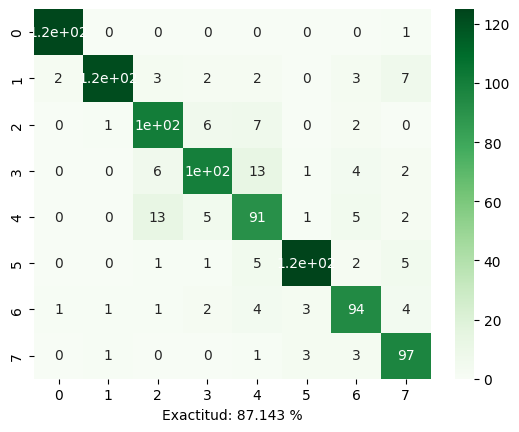

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       125
           1       0.98      0.87      0.92       141
           3       0.81      0.86      0.83       117
           4       0.86      0.79      0.83       126
           6       0.74      0.78      0.76       117
           9       0.94      0.90      0.92       139
          10       0.83      0.85      0.84       110
          11       0.82      0.92      0.87       105

    accuracy                           0.87       980
   macro avg       0.87      0.87      0.87       980
weighted avg       0.88      0.87      0.87       980



In [25]:
sns.heatmap(confusion_matrix(y_pred_RanF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF, y_test))

Validation data

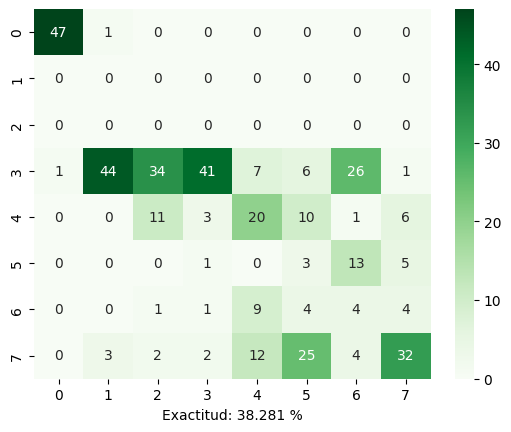

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        48
           1       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.85      0.26      0.39       160
           6       0.42      0.39      0.40        51
           9       0.06      0.14      0.09        22
          10       0.08      0.17      0.11        23
          11       0.67      0.40      0.50        80

    accuracy                           0.38       384
   macro avg       0.38      0.29      0.31       384
weighted avg       0.68      0.38      0.46       384



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [26]:
sns.heatmap(confusion_matrix(y_pred_RanF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_val, y_val))

Rotation forest

Test data

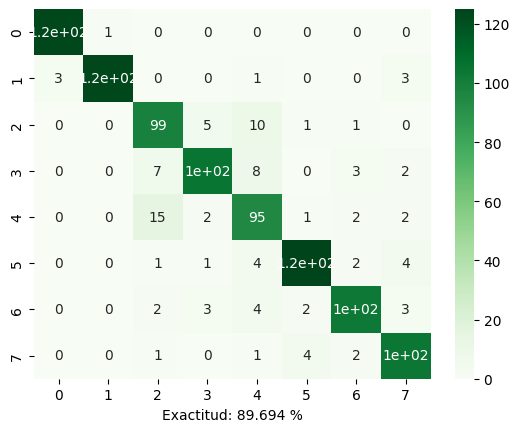

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       125
           1       0.99      0.95      0.97       131
           3       0.79      0.85      0.82       116
           4       0.91      0.84      0.87       125
           6       0.77      0.81      0.79       117
           9       0.94      0.91      0.93       137
          10       0.91      0.88      0.90       117
          11       0.88      0.93      0.90       112

    accuracy                           0.90       980
   macro avg       0.90      0.90      0.90       980
weighted avg       0.90      0.90      0.90       980



In [27]:
sns.heatmap(confusion_matrix(y_pred_RotF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF, y_test))

Validation data

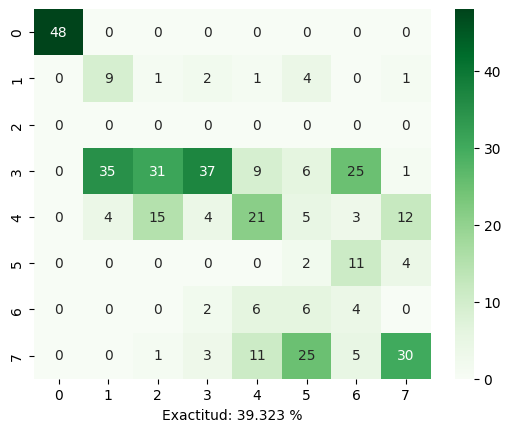

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       0.19      0.50      0.27        18
           3       0.00      0.00      0.00         0
           4       0.77      0.26      0.39       144
           6       0.44      0.33      0.38        64
           9       0.04      0.12      0.06        17
          10       0.08      0.22      0.12        18
          11       0.62      0.40      0.49        75

    accuracy                           0.39       384
   macro avg       0.39      0.35      0.34       384
weighted avg       0.62      0.39      0.45       384



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [28]:
sns.heatmap(confusion_matrix(y_pred_RotF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_val, y_val))

Artificial Neural Networks (ANN)

Test data

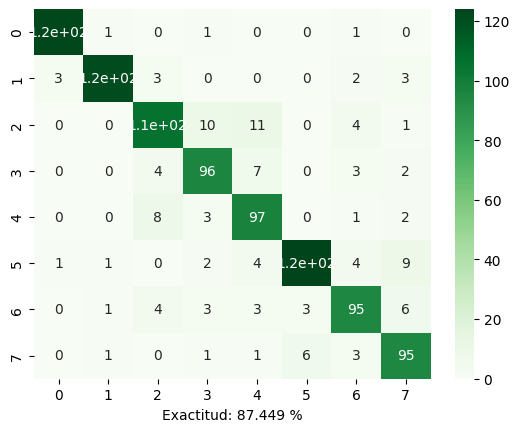

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       126
           1       0.97      0.92      0.94       132
           3       0.85      0.80      0.82       132
           4       0.83      0.86      0.84       112
           6       0.79      0.87      0.83       111
           9       0.93      0.86      0.89       145
          10       0.84      0.83      0.83       115
          11       0.81      0.89      0.84       107

    accuracy                           0.87       980
   macro avg       0.87      0.87      0.87       980
weighted avg       0.88      0.87      0.88       980



In [29]:
sns.heatmap(confusion_matrix(y_pred_ann, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann, y_test))

Validation data

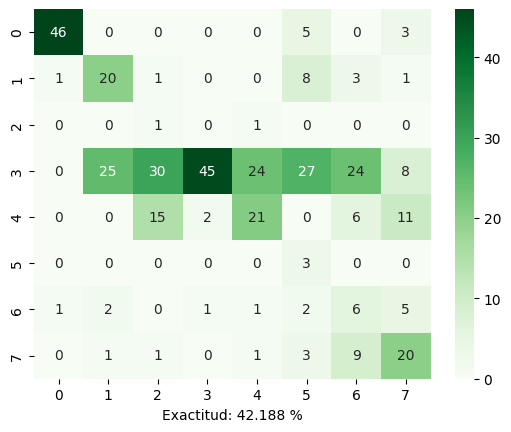

              precision    recall  f1-score   support

           0       0.96      0.85      0.90        54
           1       0.42      0.59      0.49        34
           3       0.02      0.50      0.04         2
           4       0.94      0.25      0.39       183
           6       0.44      0.38      0.41        55
           9       0.06      1.00      0.12         3
          10       0.12      0.33      0.18        18
          11       0.42      0.57      0.48        35

    accuracy                           0.42       384
   macro avg       0.42      0.56      0.38       384
weighted avg       0.73      0.42      0.47       384



In [30]:
sns.heatmap(confusion_matrix(y_pred_ann_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_val, y_val))

# Con PCA

In [31]:
pca = PCA(n_components=80)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

X_pca_val = pca.fit_transform(X_val)

In [32]:
print('Sin PCA')
print(X.shape)
print(X_pca.shape)
print('Con PCA')
print(X_val.shape)
print(X_pca_val.shape)

Sin PCA
(3264, 154)
(3264, 80)
Con PCA
(384, 154)
(384, 80)


Random forest

In [33]:
rf_pca = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_pca.fit(X_train_pca, y_train)
y_pred_RanF_pca = rf_pca.predict(X_test_pca)
y_pred_RanF_pca_val = rf_pca.predict(X_pca_val)

Rotation forest

In [34]:
clf_pca = RotationForest(n_estimators=300)
clf_pca.fit(X_train_pca, y_train)
y_pred_RotF_pca = clf_pca.predict(X_test_pca)
y_pred_RotF_pca_val = clf_pca.predict(X_pca_val)

Artificial Neural Networks (ANN)

In [35]:
le_pca = LabelEncoder()
y_train_enc = le_pca.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le_pca.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_pca, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test_pca)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann_pca = le_pca.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_pca_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_pca_val = le_pca.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


# Resultados

Random forest

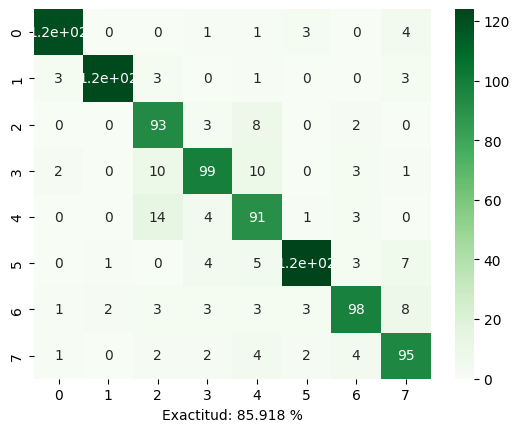

              precision    recall  f1-score   support

           0       0.94      0.93      0.94       129
           1       0.98      0.92      0.95       132
           3       0.74      0.88      0.81       106
           4       0.85      0.79      0.82       125
           6       0.74      0.81      0.77       113
           9       0.93      0.86      0.90       144
          10       0.87      0.81      0.84       121
          11       0.81      0.86      0.83       110

    accuracy                           0.86       980
   macro avg       0.86      0.86      0.86       980
weighted avg       0.86      0.86      0.86       980



In [36]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca, y_test))

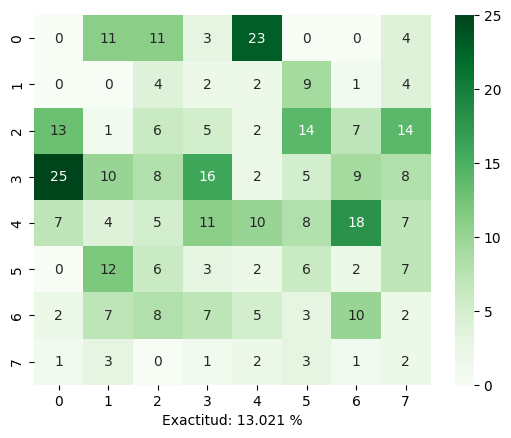

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        52
           1       0.00      0.00      0.00        22
           3       0.12      0.10      0.11        62
           4       0.33      0.19      0.24        83
           6       0.21      0.14      0.17        70
           9       0.12      0.16      0.14        38
          10       0.21      0.23      0.22        44
          11       0.04      0.15      0.07        13

    accuracy                           0.13       384
   macro avg       0.13      0.12      0.12       384
weighted avg       0.17      0.13      0.14       384



In [37]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca_val, y_val))

Rotation forest

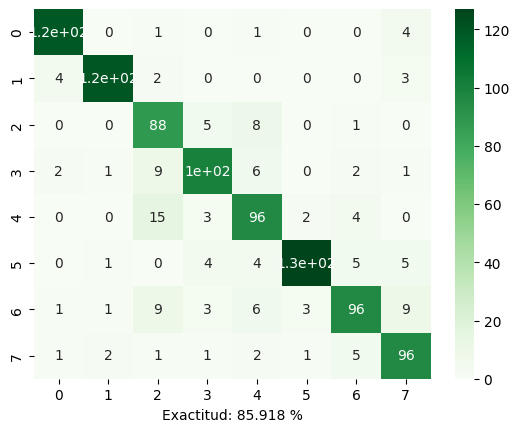

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       125
           1       0.96      0.93      0.94       129
           3       0.70      0.86      0.78       102
           4       0.86      0.83      0.84       121
           6       0.78      0.80      0.79       120
           9       0.95      0.87      0.91       146
          10       0.85      0.75      0.80       128
          11       0.81      0.88      0.85       109

    accuracy                           0.86       980
   macro avg       0.86      0.86      0.86       980
weighted avg       0.86      0.86      0.86       980



In [38]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca, y_test))

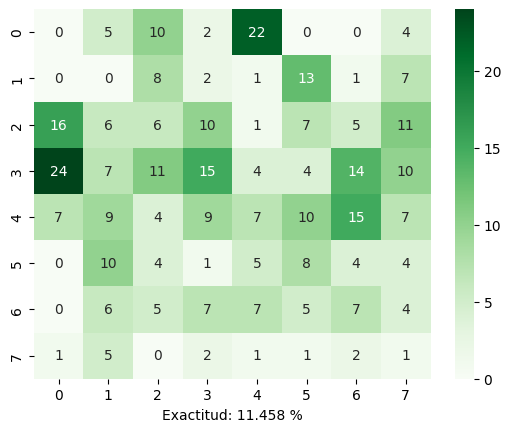

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.00      0.00      0.00        32
           3       0.12      0.10      0.11        62
           4       0.31      0.17      0.22        89
           6       0.15      0.10      0.12        68
           9       0.17      0.22      0.19        36
          10       0.15      0.17      0.16        41
          11       0.02      0.08      0.03        13

    accuracy                           0.11       384
   macro avg       0.11      0.10      0.10       384
weighted avg       0.15      0.11      0.13       384



In [39]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca_val, y_val))

Artificial Neural Networks (ANN)

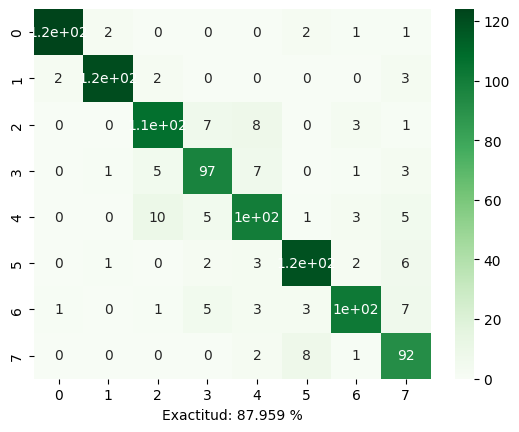

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       130
           1       0.97      0.95      0.96       128
           3       0.86      0.85      0.85       126
           4       0.84      0.85      0.84       114
           6       0.81      0.81      0.81       124
           9       0.89      0.89      0.89       133
          10       0.90      0.84      0.87       122
          11       0.78      0.89      0.83       103

    accuracy                           0.88       980
   macro avg       0.88      0.88      0.88       980
weighted avg       0.88      0.88      0.88       980



In [40]:
sns.heatmap(confusion_matrix(y_pred_ann_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca, y_test))

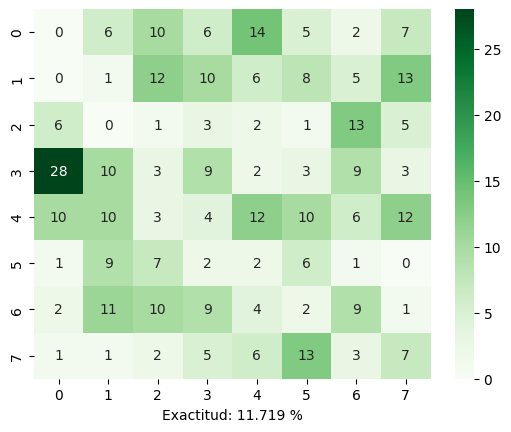

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.02      0.02      0.02        55
           3       0.02      0.03      0.03        31
           4       0.19      0.13      0.16        67
           6       0.25      0.18      0.21        67
           9       0.12      0.21      0.16        28
          10       0.19      0.19      0.19        48
          11       0.15      0.18      0.16        38

    accuracy                           0.12       384
   macro avg       0.12      0.12      0.11       384
weighted avg       0.13      0.12      0.12       384



In [41]:
sns.heatmap(confusion_matrix(y_pred_ann_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca_val, y_val))

Rpoerte de PCA

In [42]:
X

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,iemg_14,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14
0,-0.430152,0.086524,-0.397187,-0.356289,-0.297676,-0.165316,-0.463891,-0.169938,-0.237181,-0.332429,...,-0.552324,0.722403,1.064223,0.906005,-0.014357,0.681172,-0.015342,-1.040061,-1.235221,-1.104744
1,-0.271894,0.150613,-0.206629,-0.181555,-0.174315,-0.147573,-0.303444,-0.141908,0.162733,0.121545,...,-0.286886,1.047864,1.331764,1.087168,-0.004122,1.054802,-0.004774,-1.127535,-1.019358,-1.322783
2,-0.631691,0.072301,-0.613949,-0.786798,-0.548672,-0.199960,-0.766420,-0.196930,0.197338,-0.080221,...,-0.377443,0.599469,0.564619,0.736093,-0.018327,0.457203,-0.016052,-1.413758,-1.266058,-1.624683
3,-0.427290,0.155453,-0.348973,-0.296210,-0.189946,-0.165083,-0.465525,-0.169080,-0.222621,-0.382870,...,-0.105071,0.585901,0.893371,0.739042,-0.016198,0.615218,-0.016714,-1.048178,-1.204383,-1.031365
4,-0.530311,0.103665,-0.503114,-0.594952,-0.416139,-0.184708,-0.629426,-0.183665,-0.139440,-0.281987,...,-0.055815,0.591068,0.757489,0.809017,-0.019106,0.461472,-0.018765,-1.109646,-1.050195,-1.379389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3259,-0.765997,-0.231398,-0.698256,-0.902550,-0.493821,-0.208688,-0.911071,-0.210913,-0.564839,-1.089051,...,-0.032320,-0.483840,-0.587965,-0.585919,-0.026893,-0.384605,-0.025551,0.670016,0.676706,0.958241
3260,-0.719365,0.039524,-0.650387,-0.874237,-0.459605,-0.202472,-0.858684,-0.205928,-1.177267,-1.593466,...,-0.029880,-0.483696,-0.583590,-0.585612,-0.026892,-0.383872,-0.025551,0.588871,0.707544,1.341906
3261,-0.866945,0.023764,-0.810550,-1.153362,-0.618941,-0.216822,-1.094159,-0.218754,-1.644535,-2.198764,...,-0.041190,-0.482194,-0.586026,-0.583667,-0.026892,-0.383417,-0.025551,0.537840,0.615031,0.805195
3262,-0.693967,-0.167654,-0.658150,-0.856250,-0.492735,-0.199977,-0.809146,-0.203757,-0.408595,-2.299647,...,-0.032464,-0.479797,-0.575562,-0.579335,-0.026892,-0.381268,-0.025551,0.528016,0.645869,1.163701
